<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2.4 Unsupervised Learning: Clustering and Dimensionality Reduction**

**Step 1: Import Libraries**

*  pandas → handles data tables
*  numpy → numerical operations
*  matplotlib / seaborn → visualization
*  KMeans / DBSCAN → clustering algorithms
*  PCA → dimensionality reduction

In [ ]:
# Suppress warnings for clean output
import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**Step 2: Load Dataset**

*  load_wine() loads a real dataset
*  wine.data → features
*  wine.target → true labels (used later only for comparison)

In [ ]:
# Load dataset from sklearn
wine = load_wine(as_frame=True)

# Copy feature data
data = wine.data.copy()

# Add labels ONLY for interpretation (not for training)
data["wine_class"] = wine.target

# Show first rows
print(data.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  wine_class  
0      

**Step 3: Basic Inspection**
*  dataset size
*  feature names
*  missing values

In [ ]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nMissing values:")
print(data.isnull().sum())

Shape: (178, 14)

Columns:
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'wine_class'],
      dtype='object')

Missing values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
wine_class                      0
dtype: int64


**Step 4: Visualize Data Distribution**

*  how values are distributed
*  whether features are on different scales



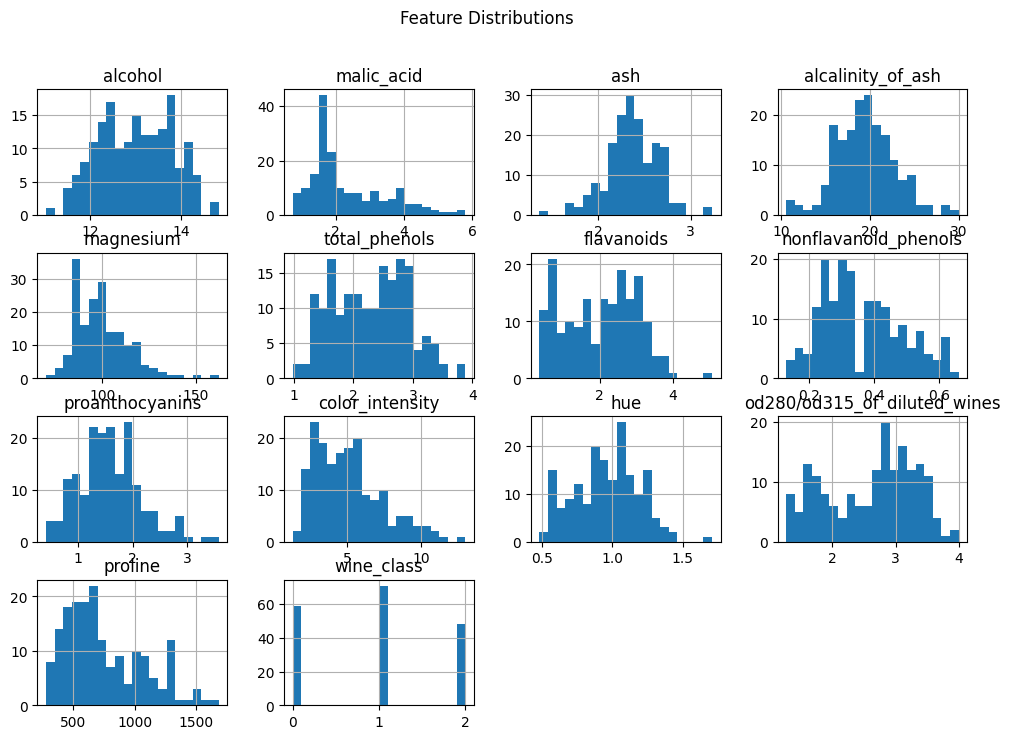

In [ ]:
data.hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

**Step 5: Remove Label for Unsupervised Learning**

*  Clustering must NOT use labels
*  Only features are used



In [ ]:
# Remove label column
X = data.drop("wine_class", axis=1)

**Step 6: Scale the Data**
*  clustering uses distance
*  large values dominate if not scaled



In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**K-MEANS CLUSTERING**

**Step 7: Elbow Method**

*  inertia = how tight clusters are
*  choose K where curve bends



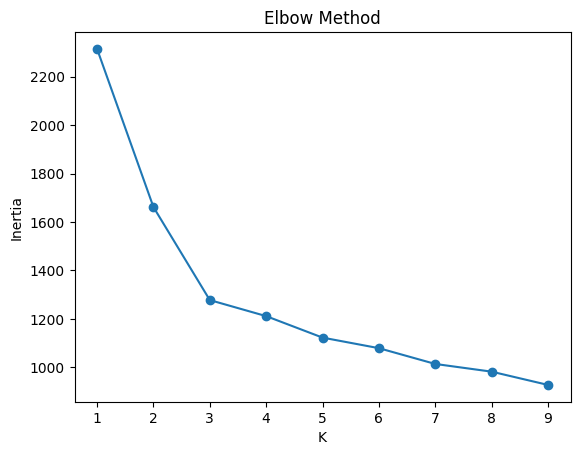

In [ ]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

**Step 8: Train K-Means**
*  model creates clusters
*  each data point gets a cluster ID



In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

data["KMeans_Cluster"] = clusters

**Step 9: Evaluate Clustering**

*  closer to 1 → good clustering
*  closer to 0 → weak clustering



In [ ]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.2848589191898987


**Step 10: Cluster Profile**
This helps interpret clusters:

*  which cluster has high alcohol?
*  which cluster has high color intensity?

👉 THIS is the most important step in unsupervised learning

In [ ]:
cluster_profile = data.groupby("KMeans_Cluster").mean()

print(cluster_profile)

                  alcohol  malic_acid       ash  alcalinity_of_ash  \
KMeans_Cluster                                                       
0               12.250923    1.897385  2.231231          20.063077   
1               13.134118    3.307255  2.417647          21.241176   
2               13.676774    1.997903  2.466290          17.462903   

                 magnesium  total_phenols  flavanoids  nonflavanoid_phenols  \
KMeans_Cluster                                                                
0                92.738462       2.247692    2.050000              0.357692   
1                98.666667       1.683922    0.818824              0.451961   
2               107.967742       2.847581    3.003226              0.292097   

                proanthocyanins  color_intensity       hue  \
KMeans_Cluster                                               
0                      1.624154         2.973077  1.062708   
1                      1.145882         7.234706  0.691961   
2    

**PCA (DIMENSIONALITY REDUCTION)**

**Step 11: Apply PCA**
*  reduces 13 features → 2 components
*  allows visualization



In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

**Step 12: Visualize Clusters**
*  shows clusters visually
*  helps understanding structure



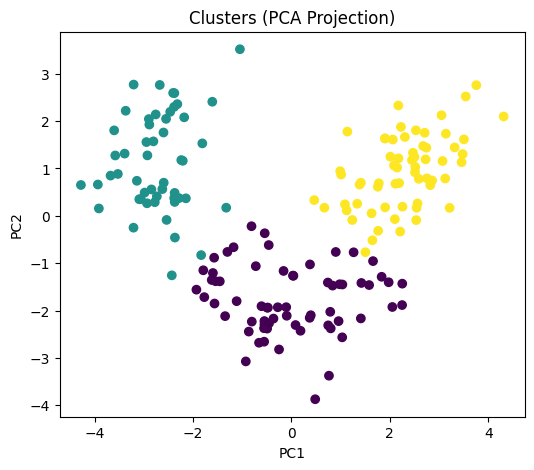

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data["KMeans_Cluster"],
    cmap='viridis'
)

plt.title("Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

**DBSCAN**

**Step 13: Apply DBSCAN**
*  DBSCAN groups by density
*  does NOT require K
*  detects outliers

In [ ]:
dbscan = DBSCAN(eps=2.2, min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

data["DBSCAN_Cluster"] = db_labels

**Step 14: Check Results**
*  -1 → noise / anomaly
*  others → clusters



In [ ]:
print(pd.Series(db_labels).value_counts())

 0    86
-1    55
 1    37
Name: count, dtype: int64


**Step 15: Visualize DBSCAN**

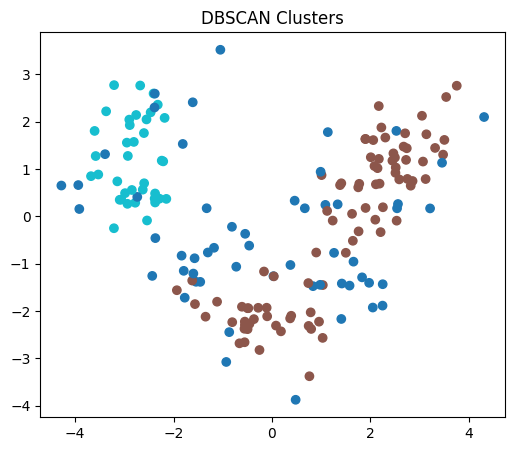

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=db_labels,
    cmap='tab10'
)

plt.title("DBSCAN Clusters")
plt.show()

**FINAL OUTPUT**

**Step 16: Save Results**

In [ ]:
data.to_csv("wine_unsupervised_output.csv", index=False)

In [ ]:
print(data.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  wine_class  KMeans_C